# Monthly GFS T2M with grib2io + Kerchunk + Icechunk

This notebook builds a **month-long time series of GFS 2-metre temperature (T2M)** from
NOAA's public S3 bucket (`noaa-gfs-bdp-pds`) without downloading the files.

## How it stays fast

Two features combine to make per-file manifest generation near-instant:

1. **`.idx` sidecar** — grib2io automatically fetches the small `url + ".idx"` text file
   that NOAA publishes alongside every GFS file.  This gives message byte offsets
   directly, so grib2io only reads the compact header bytes (Sections 0–5) rather
   than streaming the entire ~500 MB GRIB2 object.

2. **Variable filters** — passing `filters={"shortName": "TMP", ...}` to `open_grib2`
   means only the single T2M message per file is indexed; all other variables are
   skipped.  A full GFS 0.25° file contains ~700 variables; filtering to one reduces
   manifest work by ~700×.

For a full-file example (all variables, VirtualiZarr integration) see
[grib2io_s3_virtualizarr.ipynb](grib2io_s3_virtualizarr.ipynb).

**Dependencies:** `grib2io[icechunk]`, `s3fs`, `matplotlib`


In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from grib2io.icechunk import open_grib2

warnings.filterwarnings("ignore")


## 1. Configuration

Set the month, grid, and the GRIB2 message filter that selects 2-metre temperature.
`typeOfFirstFixedSurface = 103` is the GRIB2 Table 4.5 code for
*"Specified height level above ground (m)"*, and `level = 2` selects the 2 m level.


In [4]:
BUCKET   = "noaa-gfs-bdp-pds"
MONTH    = "2025-04"   # any YYYY-MM present in the bucket
GRID     = "0p25"      # 0.25-degree global grid
CYCLE    = "00"        # 00Z analysis
FORECAST = "f000"      # analysis hour (zero-lead)

storage_options = {"anon": True}

# Filter to 2-metre temperature only — skips all other variables during scanning.
# typeOfFirstFixedSurface=103 → "height above ground (m)"; level=2 → 2 m
T2M_FILTERS = {"shortName": "TMP", "typeOfFirstFixedSurface": 103}

dates = pd.date_range(MONTH, periods=pd.Period(MONTH).days_in_month, freq="D")
urls  = [
    f"s3://{BUCKET}/gfs.{d.strftime('%Y%m%d')}/{CYCLE}/atmos/"
    f"gfs.t{CYCLE}z.pgrb2.{GRID}.{FORECAST}"
    for d in dates
]

print(f"Month: {MONTH}  ({len(urls)} files)")
print("First:", urls[0])
print("Last: ", urls[-1])


Month: 2025-04  (30 files)
First: s3://noaa-gfs-bdp-pds/gfs.20250401/00/atmos/gfs.t00z.pgrb2.0p25.f000
Last:  s3://noaa-gfs-bdp-pds/gfs.20250430/00/atmos/gfs.t00z.pgrb2.0p25.f000


## 2. Verify: single file opens quickly

With the `.idx` sidecar + T2M filter, manifest generation should take only a
few seconds even for a 500 MB remote file.


In [5]:
import time

t0 = time.perf_counter()
ds_sample = open_grib2(urls[0], storage_options=storage_options, filters=T2M_FILTERS)
print(f"Opened in {time.perf_counter() - t0:.1f}s")
print(ds_sample)


  2026-05-21T19:17:05.896065Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

Opened in 1.0s
<xarray.Dataset> Size: 12MB
Dimensions:              (valid_time: 1, height_above_ground: 3, y: 721, x: 1440)
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 8B 2025-04-01
  * height_above_ground  (height_above_ground) float64 24B 2.0 80.0 100.0
Dimensions without coordinates: y, x
Data variables:
    TMP                  (valid_time, height_above_ground, y, x) float32 12MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>


In [8]:
# With the filter applied there is exactly one TMP variable (no pressure-level
# TMP in this dataset), so we can reference it by name directly.
T2M_VAR = "TMP"
print(ds_sample[T2M_VAR])


<xarray.DataArray 'TMP' (valid_time: 1, height_above_ground: 3, y: 721, x: 1440)> Size: 12MB
dask.array<open_dataset-TMP, shape=(1, 3, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 8B 2025-04-01
  * height_above_ground  (height_above_ground) float64 24B 2.0 80.0 100.0
Dimensions without coordinates: y, x
Attributes:
    _ARRAY_DIMENSIONS:         ['valid_time', 'height_above_ground', 'y', 'x']
    discipline:                0
    parameterCategory:         0
    parameterNumber:           0
    typeOfFirstFixedSurface:   103
    valueOfFirstFixedSurface:  2.0
    valid_time:                2025-04-01T00:00:00
    shortName:                 TMP
    fullName:                  Temperature
    units:                     K


## 3. Build the monthly T2M dataset

Loop over each day with the T2M filter applied.  Only the tiny `.idx` sidecar
and the matching message headers are fetched from S3 — no data payloads yet.
Temperature values are pulled on demand when `.compute()` is called later.


In [10]:
daily_t2m = []

for i, url in enumerate(urls):
    date_str = dates[i].strftime("%Y-%m-%d")
    try:
        ds  = open_grib2(url, storage_options=storage_options, filters=T2M_FILTERS)
        daily_t2m.append(ds[T2M_VAR])
        print(f"  {date_str}  OK")
    except Exception as exc:
        print(f"  {date_str}  SKIP  {exc}")

print(f"\nCollected {len(daily_t2m)} daily arrays.")


  2026-05-21T19:20:44.055217Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2025-04-01  OK
  2026-05-21T19:20:44.101255Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2025-04-02  OK
  2026-05-21T19:20:44.136615Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2025-04-03  OK
  2026-05-21T19:20:44.171941Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe f

In [11]:
# Concatenate along the existing valid_time dimension.
# This stays lazy — nothing is downloaded yet.
t2m_monthly = xr.concat(daily_t2m, dim="valid_time").isel(height_above_ground=0)

# Convert K → °C for readability
t2m_monthly = t2m_monthly - 273.15
t2m_monthly.attrs["units"] = "°C"
t2m_monthly.attrs["long_name"] = "2-metre Temperature"

print(t2m_monthly)

<xarray.DataArray 'TMP' (valid_time: 30, y: 721, x: 1440)> Size: 125MB
dask.array<sub, shape=(30, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 240B 2025-04-01 ... 2025...
    height_above_ground  float64 8B 2.0
Dimensions without coordinates: y, x
Attributes:
    _ARRAY_DIMENSIONS:         ['valid_time', 'height_above_ground', 'y', 'x']
    discipline:                0
    parameterCategory:         0
    parameterNumber:           0
    typeOfFirstFixedSurface:   103
    valueOfFirstFixedSurface:  2.0
    valid_time:                2025-04-01T00:00:00
    shortName:                 TMP
    fullName:                  Temperature
    units:                     °C
    long_name:                 2-metre Temperature


## 4. Global map — mean T2M for the month

`.mean("valid_time")` is computed first (still lazy), then `.compute()` fetches
only the bytes needed to materialise those values.

Computing monthly mean …


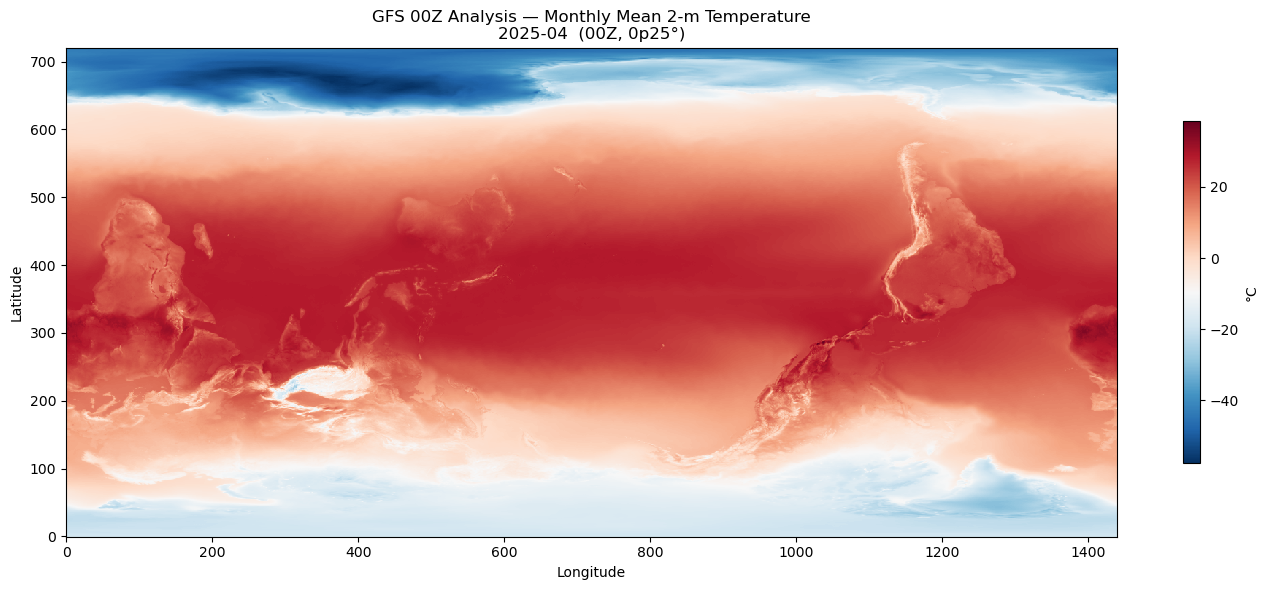

In [12]:
print("Computing monthly mean …")
t2m_mean = t2m_monthly.mean("valid_time").compute()     # triggers S3 reads

# ---- plot ----------------------------------------------------------------
lats = t2m_mean.coords.get("latitude",  t2m_mean.coords.get("y",  None))
lons = t2m_mean.coords.get("longitude", t2m_mean.coords.get("x", None))

fig, ax = plt.subplots(figsize=(14, 6))
if lats is not None and lons is not None:
    pcm = ax.pcolormesh(lons, lats, t2m_mean.values, cmap="RdBu_r", shading="auto")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
else:
    pcm = ax.imshow(t2m_mean.values, origin="upper", cmap="RdBu_r", aspect="auto")
    ax.set_xlabel("x index")
    ax.set_ylabel("y index")

plt.colorbar(pcm, ax=ax, label="°C", shrink=0.7)
ax.set_title(f"GFS 00Z Analysis — Monthly Mean 2-m Temperature\n{MONTH}  (00Z, {GRID}°)")
plt.tight_layout()
plt.show()

## 5. Point time series

Select the nearest grid point to a location of interest and plot the daily
T2M over the month.  Only the bytes for those specific grid-point chunks
are fetched.

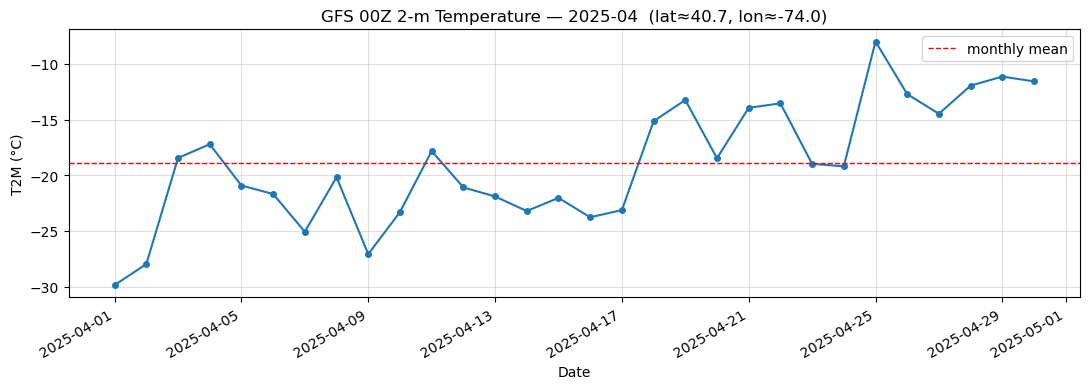


Monthly mean: -18.91 °C
Min: -29.86 °C  on 2025-04-01
Max: -8.00 °C  on 2025-04-25


In [17]:
# Location of interest (change as desired)
TARGET_LAT = 40.71   # New York City
TARGET_LON = -74.01  # (negative = West)

lats = t2m_monthly.coords.get("latitude",  t2m_monthly.coords.get("y",  None))
lons = t2m_monthly.coords.get("longitude", t2m_monthly.coords.get("x", None))

# if lats is not None and lons is not None:
#     # If longitude is stored 0-360, wrap target
#     if float(lons.min()) >= 0 and TARGET_LON < 0:
#         TARGET_LON += 360.0
#     ts = t2m_monthly.sel(
#         {lats.name: TARGET_LAT, lons.name: TARGET_LON},
#         method="nearest"
#     ).compute()
# else:
#     # Fallback: pick centre pixel
#     ny, nx = t2m_monthly.shape[-2], t2m_monthly.shape[-1]
#     ts = t2m_monthly.isel(y=ny // 2, x=nx // 2).compute()
ts = t2m_monthly.isel(x=0,y=0).compute()
times = pd.to_datetime(ts.coords["valid_time"].values)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(times, ts.values.ravel(), marker="o", linewidth=1.5, markersize=4)
ax.axhline(float(ts.mean()), color="red", linestyle="--", linewidth=1, label="monthly mean")
ax.set_xlabel("Date")
ax.set_ylabel("T2M (°C)")
ax.set_title(f"GFS 00Z 2-m Temperature — {MONTH}  (lat≈{TARGET_LAT:.1f}, lon≈{TARGET_LON:.1f})")
ax.legend()
ax.grid(alpha=0.4)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\nMonthly mean: {float(ts.mean()):.2f} °C")
print(f"Min: {float(ts.min()):.2f} °C  on {times[int(ts.argmin())].date()}")
print(f"Max: {float(ts.max()):.2f} °C  on {times[int(ts.argmax())].date()}")

## 6. Spatial standard deviation — day-to-day variability

Where is month-to-month variability highest?  Compute standard deviation
along `valid_time` and plot.

In [ ]:
print("Computing temporal standard deviation …")
t2m_std = t2m_monthly.std("valid_time").compute()

lats = t2m_std.coords.get("latitude",  t2m_std.coords.get("y",  None))
lons = t2m_std.coords.get("longitude", t2m_std.coords.get("x", None))

fig, ax = plt.subplots(figsize=(14, 6))
if lats is not None and lons is not None:
    pcm = ax.pcolormesh(lons, lats, t2m_std.values, cmap="YlOrRd", shading="auto")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
else:
    pcm = ax.imshow(t2m_std.values, origin="upper", cmap="YlOrRd", aspect="auto")

plt.colorbar(pcm, ax=ax, label="°C", shrink=0.7)
ax.set_title(f"GFS 00Z — Day-to-Day T2M Standard Deviation\n{MONTH}  ({GRID}°)")
plt.tight_layout()
plt.show()